In [1]:
# for non-standard residues
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

# cif to pdb, protein and ligands
from Bio.PDB import MMCIFParser, PDBIO, Select

# non-standard residue handling
from rdkit import Chem
from rdkit.Chem import AllChem

# to make water
from scipy.constants import N_A
from mendeleev import element

# general
import os
import yaml
import glob
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# to fix Bolts OXT
from pdbfixer import PDBFixer


# OFF
from openff.toolkit import Molecule, Topology
from openff.units import unit as off_unit
from openff.toolkit import ForceField as OFF_ForceField
from openff.interchange import Interchange
from openff.interchange.components._packmol import pack_box

# https://docs.openforcefield.org/projects/toolkit/en/stable/api/generated/openff.toolkit.utils.toolkits.ToolkitRegistry.html
from openff.toolkit.utils import GLOBAL_TOOLKIT_REGISTRY, AmberToolsToolkitWrapper

# OMM
from openmm import LangevinIntegrator, Vec3
from openmm.app import Simulation, PDBReporter, StateDataReporter, PDBFile
from openmm.app import Modeller
from openmm.app import ForceField as OMM_ForceField
from openmm import unit as omm_unit

# warnings
import warnings
from rdkit import RDLogger
from openff.interchange.warnings import InterchangeCombinationWarning


# configs
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=InterchangeCombinationWarning)  # trustmebro

# AmberTools recognition
GLOBAL_TOOLKIT_REGISTRY.register_toolkit(AmberToolsToolkitWrapper())

# Inspiration
# https://pubs.acs.org/doi/10.1021/acs.jcim.1c00998
# https://docs.openforcefield.org/en/latest/examples/openforcefield/openff-interchange/protein_ligand/protein_ligand.html
# https://github.com/openforcefield/openff-interchange/blob/v0.5.2/examples/protein_ligand/protein_ligand.ipynb

In [2]:
# ENV = "/mnt/sds-hd/sd25g005/openmm"
ENV = os.environ.get("CONDA_PREFIX", "/opt/conda/envs/openmm")

packmol_dir = str(Path(ENV) / "bin" / "packmol")
os.environ["PATH"] = os.pathsep.join([os.environ.get("PATH", ""), packmol_dir])

# intentional hardcode for reproducibility in a fragile env
env_site_packages = ENV + "/lib/python3.12/site-packages"

In [3]:
# hide this away? or make it pretty?
import xml.etree.ElementTree as ET

amber_path = Path(Path(env_site_packages) / "openmm/app/data/amber14")

xml_files = amber_path.glob("*.xml")

residue_names = sorted(
    {
        res.get("name")
        for f in xml_files
        for res in ET.parse(f).getroot().findall(".//Residue")
        if res.get("name") is not None
    }
)

standard_aa_names = residue_names + ["HIS"]  # do not ask

## File Input

In [4]:
WORKDIR = Path.cwd()

input_file = WORKDIR / "md_inputs/G3_example_model_0.cif"
boltz_input_file = WORKDIR / "md_inputs/G3_example.yaml"

basename = Path(input_file).with_suffix("").name

In [5]:
cif_dict = MMCIF2Dict(input_file)

nonstandard_residues = cif_dict.get("_pdbx_nonpoly_scheme.mon_id", [])
nonstandard_chains = cif_dict.get("_pdbx_nonpoly_scheme.pdb_strand_id", [])

smiles = cif_dict.get("_chem_comp.pdbx_smiles", [])

# Prefer SMILES from dict (AlphaFold); fall back to YAML if dict is missing/empty (Boltz)
if nonstandard_residues:
    if smiles:
        nonstandard_smiles = [
            dict(zip(cif_dict["_chem_comp.id"], smiles)).get(ccd)
            for ccd in nonstandard_residues
        ]
    else:
        with open(boltz_input_file, "r") as f:
            nonstandard_smiles = [
                entry["ligand"]["smiles"]
                for entry in yaml.safe_load(f).get("sequences", [])
                if "ligand" in entry and "smiles" in entry["ligand"]
            ]

## Split CIF File in protein.pdb and non-standard.sdf

In [6]:
# https://biopython.org/docs/dev/Tutorial/chapter_pdb.html#writing-pdb-files
parser = MMCIFParser()
structure = parser.get_structure("complex", input_file)

io = PDBIO()
io.set_structure(structure)


# does not work for glycosylation
class ProteinOnly(Select):
    def accept_residue(self, residue):
        return residue.get_resname() not in nonstandard_residues


io.save(f"{basename}_protein.pdb", ProteinOnly())

In [7]:
# this will most likely not work with glycosylation

# rename long residue names to avoid conflicts with pdb file format
for residue in structure.get_residues():
    residue.resname = residue.get_resname()[:3]

nonstandard_residues = [resname[:3] for resname in nonstandard_residues]

# https://github.com/biopython/biopython/blob/master/Bio/PDB/PDBIO.py#L62
if nonstandard_residues:
    for chain, resname in zip(nonstandard_chains, nonstandard_residues):

        class Sel(Select):
            def accept_residue(self, residue, cn=chain, rn=resname):
                return residue.get_parent().id == cn and residue.get_resname() == rn

        io.save(f"{basename}_{chain}_{resname}.pdb", select=Sel())

In [8]:
# https://www.rdkit.org/docs/source/rdkit.Chem.rdmolfiles.html#rdkit.Chem.rdmolfiles.MolToMolFile
# this does not work for ions
if nonstandard_residues:
    for resname, smiles, chain in zip(
        nonstandard_residues, nonstandard_smiles, nonstandard_chains
    ):
        pdb_mol = Chem.MolFromPDBFile(
            f"{basename}_{chain}_{resname}.pdb", removeHs=True
        )
        # use smiles as template where H have to go
        template = Chem.MolFromSmiles(smiles)
        mol = AllChem.AssignBondOrdersFromTemplate(template, pdb_mol)
        Chem.SanitizeMol(mol)
        mol = Chem.AddHs(mol, addCoords=True)
        Chem.MolToMolFile(mol, f"{basename}_{chain}_{resname}.sdf")

# Protein

In [9]:
# only for boltz
# https://github.com/openmm/pdbfixer/blob/master/pdbfixer/pdbfixer.py#L1207

fixer = PDBFixer(f"{basename}_protein.pdb")
fixer.findMissingResidues()  # locate missing residues (required for OXT)
fixer.findMissingAtoms()  # adds whole residues if any are absent
fixer.addMissingAtoms()
PDBFile.writeFile(fixer.topology, fixer.positions, open(f"{basename}_protein.pdb", "w"))

In [10]:
pdb = PDBFile(f"{basename}_protein.pdb")
modeller = Modeller(pdb.topology, pdb.positions)

### Protein Forcefield (OMM)

In [11]:
forcefield = OMM_ForceField(  # should not need explicit paths, but does
    "amber14-all.xml",
    "tip3p.xml",
    env_site_packages + "/openforcefields/offxml/openff-2.2.0.offxml",
)

# https://docs.openmm.org/latest/api-python/generated/openmm.app.modeller.Modeller.html#openmm.app.modeller.Modeller.addHydrogens
modeller.addHydrogens(forcefield, pH=7)
# write tmp.pdb file
PDBFile.writeFile(
    modeller.topology, modeller.positions, open(f"{basename}_protein_H.pdb", "w")
)  # receptor only, with hydrogens, no water

In [12]:
# translate the Protein object from openMM to openFF
# requires Hydrogens
protein_with_crystal_water = Topology.from_pdb(f"{basename}_protein_H.pdb")

# splice out the protein(s) as a Molecule object
protein_molecules = [
    protein_with_crystal_water.molecule(n)
    for n in range(protein_with_crystal_water.n_molecules)
]

### Protein Forcefield (OFF)

In [13]:
# https://github.com/openforcefield/openff-interchange/blob/main/openff/interchange/components/interchange.py#L93
protein_interchange = Interchange.from_smirnoff(
    # impropers variant because Interchange doesn’t support Amber’s improper torsion function.
    force_field=OFF_ForceField("ff14sb_off_impropers_0.0.4.offxml"),
    # topology=protein.to_topology(),
    topology=protein_molecules,
)

# Ligand

In [14]:
# https://docs.openforcefield.org/projects/toolkit/en/stable/api/generated/openff.toolkit.topology.Molecule.html#openff.toolkit.topology.Molecule.from_file
# If there is a single molecule in the file, a Molecule is returned; otherwise, a list of Molecule objects is returned.
# We need single molecules for reasons

# this is dangerous for new users
files = sorted(glob.glob(f"{basename}_*.sdf"))
# molecules = [Molecule.from_file(f"{basename}_{resname}.sdf") for resname  in nonstandard_residues]
molecules = [Molecule.from_file(f) for f in files]

# one could do - but then positions glitch again
# https://docs.openforcefield.org/projects/toolkit/en/stable/api/generated/openff.toolkit.topology.Molecule.html#openff.toolkit.topology.Molecule.from_rdkit

In [15]:
if molecules:
    ligand_interchange = Interchange.from_smirnoff(
        force_field=OFF_ForceField(
            "openff_unconstrained-2.0.0.offxml"
        ),  # ligand force field
        topology=molecules,
    )

## Combine Protein and Ligand

In [16]:
if molecules:
    docked_interchange = protein_interchange.combine(ligand_interchange)
    docked_topology = Topology.from_molecules(protein_molecules + molecules)
else:
    docked_interchange = protein_interchange
    docked_topology = Topology.from_molecules(
        protein_molecules
    )  # check this for only protein

## Make the Simulation Box

In [17]:
# take entire solute into account
coords = [
    docked_topology.molecule(i).conformers[0]
    for i in range(docked_topology.n_molecules)
]
xyz = np.vstack(coords)

centroid = (
    xyz.sum(axis=0) / xyz.shape[0]
)  # unit of centroid is nm, but displayed as angstrom - do not be fooled

In [18]:
centered = xyz.to(off_unit.nanometer) - centroid
mins = centered[:, :3].magnitude.min(axis=0)
maxs = centered[:, :3].magnitude.max(axis=0)

padding = 2
aligned_box_vectors = np.diag(maxs - mins + padding) * off_unit.nanometer

volume = float(
    (aligned_box_vectors.diagonal().prod()).to(off_unit.centimeter**3).magnitude
)

### Fill with Water

In [19]:
# this assumes a rho of 1
mass_H2O = 2 * element("H").atomic_weight + element("O").atomic_weight

# number of TIP3P water molecules for a density of 1 g·cm⁻³
n_water = int(round(volume * N_A / mass_H2O))

### Add Ions

In [20]:
# did not include Na+, probably not ligand charge either
total_charge = round(sum(docked_interchange["Electrostatics"].charges.values()), 3)

In [21]:
# Define the solvent molecules and ions
solvent_mols = [Molecule.from_smiles(s) for s in ("O", "[Cl-]", "[Na+]")]

for mol in solvent_mols:
    mol.generate_conformers(n_conformers=1)

# Amount of copies of each solvent molecule
copies = [n_water, max(0, int(total_charge.m)), max(0, -int(total_charge.m))]

## Construct the Box


In [22]:
# topology of the solvent molecues
# https://github.com/openforcefield/openff-interchange/blob/main/openff/interchange/components/_packmol.py#L595

packed_topology = pack_box(
    molecules=solvent_mols,
    number_of_copies=copies,
    solute=docked_topology,
    box_vectors=aligned_box_vectors,
    center_solute=True,
)

packed_topology.to_file(f"{basename}_packed.pdb")

## Create Solvent Topology


In [23]:
water_interchange = Interchange.from_smirnoff(
    force_field=OFF_ForceField("openff_unconstrained-2.0.0.offxml"),
    topology=[solvent_mols[0]] * copies[0]
    + [solvent_mols[2]] * copies[2]
    + [solvent_mols[1]] * copies[1],
)

## Combine Solvent and Solute Topology

In [24]:
system_interchange = docked_interchange.combine(water_interchange)
# add positions back
system_interchange.positions = packed_topology.get_positions()
system_interchange.box = packed_topology.box_vectors

In [26]:
# export to openMM|
openmm_topology = system_interchange.topology.to_openmm(ensure_unique_atom_names=False)
openmm_system = system_interchange.to_openmm()

## Simulation Time!

In [27]:
integrator = LangevinIntegrator(
    300 * omm_unit.kelvin, 1 / omm_unit.picosecond, 0.002 * omm_unit.picoseconds
)
simulation = Simulation(openmm_topology, openmm_system, integrator)

### Update Positions

In [28]:
# https://docs.openmm.org/latest/api-python/generated/openmm.openmm.Context.html#openmm.openmm.Context.setPositions
pos_array = np.asarray(system_interchange.positions / omm_unit.nanometer, dtype=float)
vecs = [
    Vec3(float(x), float(y), float(z)) for x, y, z in pos_array
] * omm_unit.nanometer

simulation.context.setPositions(vecs)

In [29]:
simulation.minimizeEnergy()

1 warning generated.


In [30]:
log_file = f"{basename}_log.txt"
simulation.reporters.append(PDBReporter(f"{basename}_output.pdb", 100))
simulation.reporters.append(
    StateDataReporter(log_file, 100, step=True, potentialEnergy=True, temperature=True)
)

simulation.step(10000)

In [31]:
# Read OpenMM StateDataReporter log

df = pd.read_csv(log_file, header=0)
df.columns = [c.lstrip("#").strip('"') for c in df.columns]
df

,Step,Potential Energy (kJ/mole),Temperature (K)
0,100,-28389.864739,56.679984
1,200,-27693.199522,99.855043
2,300,-27177.202242,134.415272
3,400,-26827.354599,168.537065
4,500,-26329.710753,184.120912
...,...,...,...
95,9600,-23529.740831,295.858315
96,9700,-23789.698965,306.117334
97,9800,-23526.026343,286.800167
98,9900,-23789.852337,296.274140


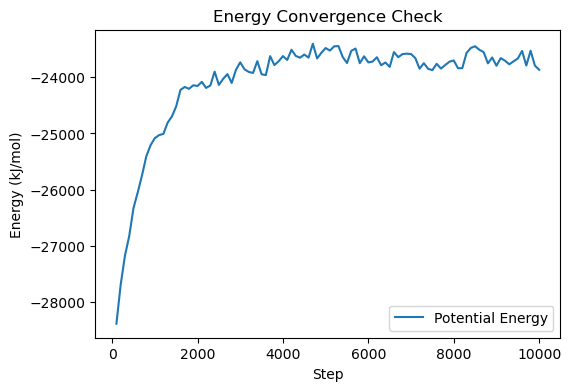

In [32]:
# Plot directly
plt.figure(figsize=(6, 4))
plt.plot(df["Step"], df["Potential Energy (kJ/mole)"], label="Potential Energy")
plt.xlabel("Step")
plt.ylabel("Energy (kJ/mol)")
plt.legend()
plt.title("Energy Convergence Check")
plt.show()